# **Notebook 3.3 -- Shallow network regions**

El propósito de este notebook es calcular el número máximo posible de regiones lineales, como se ve en la figura 3.9 del libro.

Trabaja a través de las celdas a continuación, ejecutando cada una a su vez. En varios lugares verás las palabras "TAREA PENDIENTE". Sigue las instrucciones en estos lugares y escribe código para completar las funciones. También hay preguntas intercaladas en el texto.

Contáctame en udlbookmail@gmail.com si encuentras algún error o tienes alguna sugerencia.

In [1]:
# Importa la librería math
import numpy as np
# Importa la librería de trazado
import matplotlib.pyplot as plt
# Importa la librería math
import math

El número de regiones $N$ creadas por una red neuronal poco profunda con $D_i$ entradas y $D$ unidades ocultas viene dado por la fórmula de Zaslavsky:

\begin{equation}N = \sum_{j=0}^{D_{i}}\binom{D}{j}=\sum_{j=0}^{D_{i}} \frac{D!}{(D-j)!j!} \end{equation} <br>

In [2]:
def number_regions(Di, D):
  # TAREA PENDIENTE -- implementa la fórmula de Zaslavsky
  # Necesitarás usar math.factorial() https://www.geeksforgeeks.org/factorial-in-python/
  # Reemplaza este código
  Dfat = math.factorial(D)
  N = 0
  for j in range(Di+1):
    N += (Dfat / (math.factorial(D - j) * math.factorial(j)))


  return N

In [3]:
# Calcula el número de regiones para una entrada 2D (Di=2) y 3 unidades ocultas (D=3) como en la figura 3.8j
N = number_regions(2, 3)
print(f"Di=2, D=3, Número de regiones = {int(N)}, Valor verdadero = 7")

Di=2, D=3, Número de regiones = 7, Valor verdadero = 7


In [4]:
# Calcula el número de regiones para una entrada 10D (Di=2) y 50 unidades ocultas (D=50)
N = number_regions(10, 50)
print(f"Di=10, D=50, Número de regiones = {int(N)}, Valor verdadero = 13432735556")

Di=10, D=50, Número de regiones = 13432735556, Valor verdadero = 13432735556


Esto funciona, pero hay una complicación. Si el número de unidades ocultas $D$ es menor que el número de dimensiones de entrada $D_i$, la fórmula fallará. Cuando este es el caso, solo hay $2^D$ regiones (consulta la figura 3.10 para entender por qué).

Vamos a demostrar esto:

In [5]:
# Muestra que el cálculo falla cuando $D_i < D$
try:
  N = number_regions(10, 8)
  print(f"Di=10, D=8, Número de regiones = {int(N)}, Valor verdadero = 256")
except Exception as error:
    print("Ocurrió una excepción:", error)

Ocurrió una excepción: factorial() not defined for negative values


In [6]:
# Realicemos el cálculo correctamente cuando D<Di (ver figura 3.10 del libro)
D = 8; Di = 10
N = np.power(2,D)
# Podemos hacer esto de forma equivalente llamando a number_regions con D dos veces
# Piensa por qué esto funciona
N2 = number_regions (D,D)
print(f"Di=10, D=8, Número de regiones = {int(N)}, Número de regiones = {int(N2)}, Valor verdadero = 256")

Di=10, D=8, Número de regiones = 256, Número de regiones = 256, Valor verdadero = 256


Contando regiones para 1 dimensiones de entrada
Contando regiones para 5 dimensiones de entrada
Contando regiones para 10 dimensiones de entrada
Contando regiones para 50 dimensiones de entrada
Contando regiones para 100 dimensiones de entrada


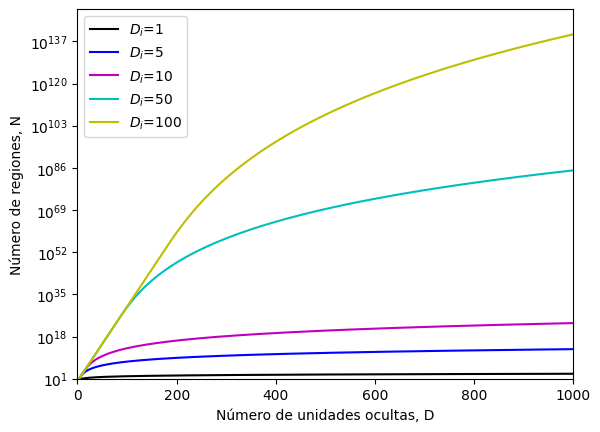

In [7]:
# Ahora tracemos el gráfico de la figura 3.9a
dims = np.array([1,5,10,50,100])
regions = np.zeros((dims.shape[0], 1000))
for c_dim in range(dims.shape[0]):
    D_i = dims[c_dim]
    print (f"Contando regiones para {D_i} dimensiones de entrada")
    for D in range(1000):
        regions[c_dim, D] = number_regions(np.min([D_i,D]), D)

fig, ax = plt.subplots()
ax.semilogy(regions[0,:],'k-')
ax.semilogy(regions[1,:],'b-')
ax.semilogy(regions[2,:],'m-')
ax.semilogy(regions[3,:],'c-')
ax.semilogy(regions[4,:],'y-')
ax.legend(['$D_i$=1', '$D_i$=5', '$D_i$=10', '$D_i$=50', '$D_i$=100'])
ax.set_xlabel("Número de unidades ocultas, D")
ax.set_ylabel("Número de regiones, N")
plt.xlim([0,1000])
plt.ylim([1e1,1e150])
plt.show()

In [8]:
# Ahora calcularemos y trazaremos el número de regiones en función del número de parámetros como en la figura 3.9b
# Primero escribamos una función que calcule el número de parámetros en función de la dimensión de entrada y el número de capas ocultas (asumiendo solo una salida)

def number_parameters(D_i, D):
  # TAREA PENDIENTE -- reemplaza este código con el cálculo apropiado
  N = (D_i * D) + (2 * D) + 1

  return N ;

In [9]:
# Ahora probemos el código
N = number_parameters(10, 8)
print(f"Di=10, D=8, Número de parámetros = {int(N)}, Valor verdadero = 97")

Di=10, D=8, Número de parámetros = 97, Valor verdadero = 97


Contando regiones para 1 dimensiones de entrada
Contando regiones para 5 dimensiones de entrada
Contando regiones para 10 dimensiones de entrada
Contando regiones para 50 dimensiones de entrada
Contando regiones para 100 dimensiones de entrada


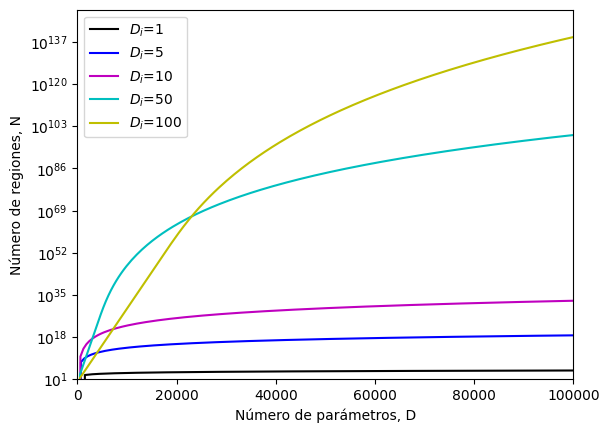

In [10]:
# Ahora tracemos el gráfico de la figura 3.9a (tarda ~1min)
dims = np.array([1,5,10,50,100])
regions = np.zeros((dims.shape[0], 200))
params = np.zeros((dims.shape[0], 200))

# Calcularemos las cinco líneas por separado esta vez para hacerlo más rápido
for c_dim in range(dims.shape[0]):
    D_i = dims[c_dim]
    print (f"Contando regiones para {D_i} dimensiones de entrada")
    for c_hidden in range(1, 200):
        # Iterar sobre diferentes rangos de número de variables ocultas para diferentes tamaños de entrada
        D = int(c_hidden * 500 / D_i)
        params[c_dim, c_hidden] =  D_i * D +D + D +1
        regions[c_dim, c_hidden] = number_regions(np.min([D_i,D]), D)

fig, ax = plt.subplots()
ax.semilogy(params[0,:], regions[0,:],'k-')
ax.semilogy(params[1,:], regions[1,:],'b-')
ax.semilogy(params[2,:], regions[2,:],'m-')
ax.semilogy(params[3,:], regions[3,:],'c-')
ax.semilogy(params[4,:], regions[4,:],'y-')
ax.legend(['$D_i$=1', '$D_i$=5', '$D_i$=10', '$D_i$=50', '$D_i$=100'])
ax.set_xlabel("Número de parámetros, D")
ax.set_ylabel("Número de regiones, N")
plt.xlim([0,100000])
plt.ylim([1e1,1e150])
plt.show()